# Praktikum 1: Segmentasi Menggunakan Thresholding Global dan Otsu

## Tujuan
Praktikum ini bertujuan untuk menerapkan metode segmentasi berbasis **thresholding** pada citra grayscale. Kita akan membandingkan dua pendekatan:
- **Thresholding Global (Manual):** Menentukan nilai ambang (threshold) secara manual untuk seluruh citra. Piksel di atas nilai ambang dianggap sebagai objek, sisanya sebagai latar belakang.
- **Metode Otsu:** Metode thresholding otomatis yang menentukan nilai ambang optimal dengan cara **memaksimalkan varians antar kelas** (between-class variance). Cocok untuk citra dengan histogram bimodal.

## Library yang Digunakan
- `matplotlib` — untuk visualisasi citra
- `scikit-image (skimage)` — untuk memuat data citra dan menghitung threshold Otsu

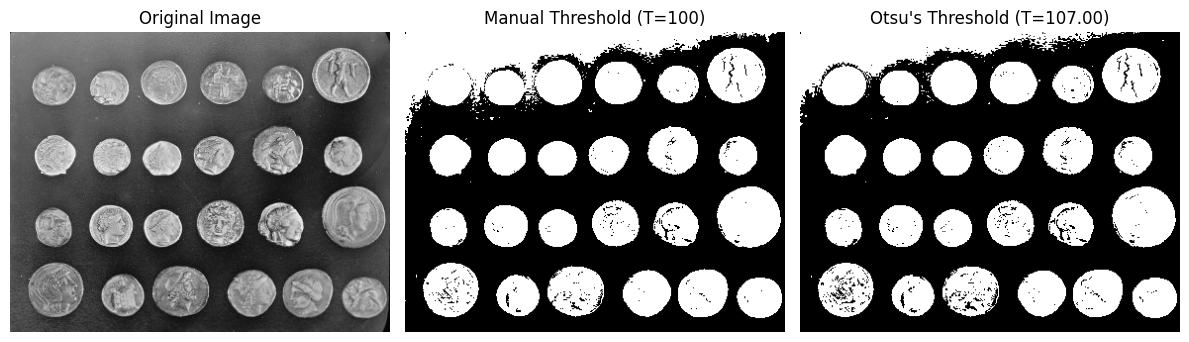

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

## Kesimpulan Praktikum 1

Dari hasil praktikum ini dapat disimpulkan:

1. **Thresholding Manual (Global)** memisahkan piksel berdasarkan nilai ambang yang ditentukan secara subjektif. Hasilnya bisa kurang optimal jika nilai ambang tidak dipilih dengan tepat — terlalu rendah akan menyertakan banyak latar belakang, terlalu tinggi akan menghilangkan bagian objek.

2. **Metode Otsu** secara otomatis mencari nilai ambang optimal berdasarkan distribusi histogram citra. Pada citra `coins` yang memiliki histogram bimodal (ada dua kelompok intensitas jelas antara koin dan latar belakang), metode Otsu berhasil memisahkan objek dengan lebih baik dibanding thresholding manual.

3. Nilai threshold Otsu yang dihasilkan mencerminkan batas alami antara dua kelompok piksel dominan dalam citra, sehingga menghasilkan segmentasi yang lebih akurat dan tidak bergantung pada penilaian subjektif.

# Praktikum 2: Segmentasi Menggunakan Region Growing (Contoh Sederhana)

## Tujuan
Praktikum ini mendemonstrasikan konsep dasar **Region Growing**, yaitu metode segmentasi berbasis wilayah yang mengelompokkan piksel berdasarkan:
- **Kedekatan spasial** — piksel harus bertetangga satu sama lain
- **Kesamaan properti** — perbedaan intensitas tidak boleh melebihi nilai toleransi tertentu

Kita menggunakan fungsi `segmentation.flood()` dari `scikit-image` sebagai pendekatan yang konsepnya mirip dengan region growing — dimulai dari satu titik **seed (benih)**, lalu "tumbuh" ke piksel tetangga yang intensitasnya masih dalam batas toleransi.

## Library yang Digunakan
- `numpy` — manipulasi array citra
- `matplotlib` — visualisasi hasil
- `scikit-image (skimage)` — memuat citra dan fungsi flood fill

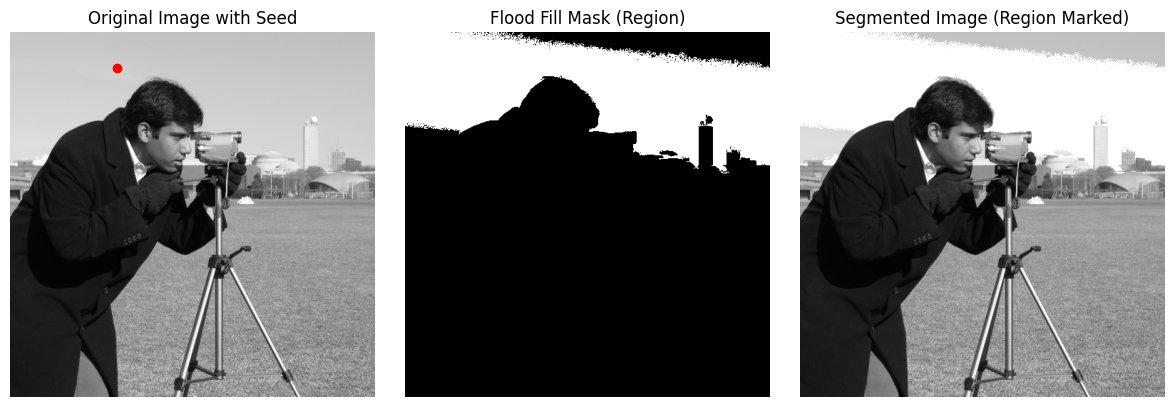

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Kesimpulan Praktikum 2

Dari hasil praktikum ini dapat disimpulkan:

1. **Region Growing (Flood Fill)** bekerja dengan cara "menumbuhkan" wilayah dari satu titik seed ke piksel-piksel tetangganya yang memenuhi kriteria kesamaan intensitas.

2. **Parameter `tolerance`** sangat menentukan ukuran region yang terbentuk:
   - Nilai tolerance **kecil** → region tumbuh sempit, hanya piksel yang sangat mirip yang ikut bergabung
   - Nilai tolerance **besar** → region tumbuh lebih luas, lebih banyak piksel yang dianggap "sama"

3. **Pemilihan titik seed** juga sangat berpengaruh — seed yang diletakkan di area berbeda akan menghasilkan region yang sama sekali berbeda.

4. Metode ini cocok untuk kasus di mana objek yang ingin disegmentasi memiliki intensitas yang relatif seragam dan berbeda jelas dari sekitarnya.

# Praktikum 3: Segmentasi Citra Berwarna Menggunakan K-Means Clustering

## Tujuan
Praktikum ini menerapkan metode **K-Means Clustering** untuk mensegmentasi citra berwarna berdasarkan nilai warna piksel. Berbeda dengan thresholding yang hanya menggunakan intensitas, K-Means mengelompokkan piksel ke dalam **K klaster** berdasarkan kemiripan fitur warnanya.

## Konsep Utama
- **K-Means Clustering:** Algoritma iteratif yang mempartisi piksel ke dalam K kelompok. Setiap piksel dimasukkan ke klaster dengan pusat (centroid) terdekat, lalu centroid diperbarui terus hingga konvergen.
- **Ruang Warna Lab:** Kita mengkonversi citra dari RGB ke **CIE Lab** sebelum clustering. Ruang warna Lab dirancang agar perbedaan numerik antar warna lebih sesuai dengan persepsi mata manusia, sehingga hasil clustering lebih natural.

## Library yang Digunakan
- `numpy` — manipulasi array
- `matplotlib` — visualisasi hasil
- `scikit-image (skimage)` — memuat citra dan konversi ruang warna
- `scikit-learn (sklearn)` — algoritma K-Means
- `warnings` — menyembunyikan peringatan versi library


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/c4/0ab22726a04ede56f689476b760f98f8f46607caecff993017ac1b64aa5d/scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0

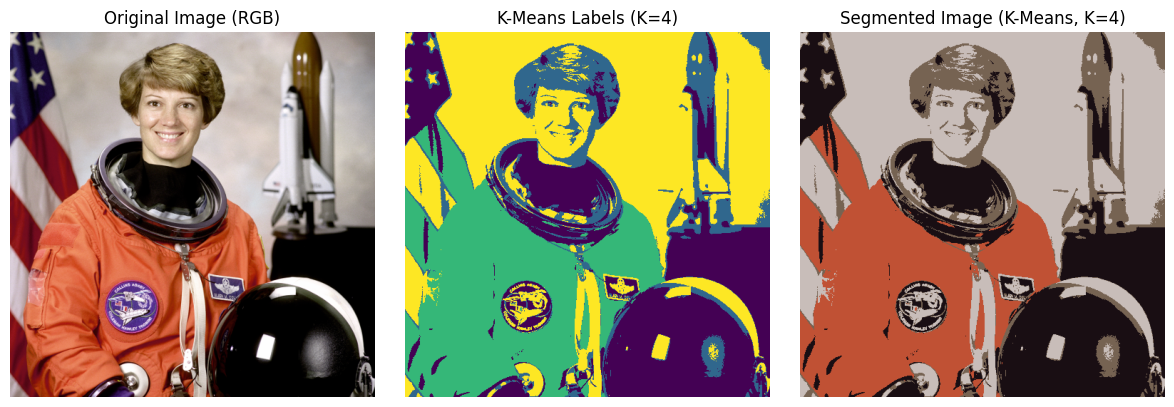

In [7]:
import numpy as np
import matplotlib.pyplot as plt
!pip install scikit-learn
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Kesimpulan Praktikum 3

Dari hasil praktikum ini dapat disimpulkan:

1. **K-Means Clustering** mampu mensegmentasi citra berwarna dengan mengelompokkan piksel berdasarkan kemiripan warna tanpa memerlukan informasi spasial secara eksplisit.

2. **Nilai K (jumlah klaster)** sangat mempengaruhi hasil segmentasi:
   - K kecil → segmentasi lebih kasar, detail warna berkurang
   - K besar → segmentasi lebih detail, namun lebih lambat dan bisa over-segmentasi

3. **Penggunaan ruang warna Lab** memberikan hasil yang lebih natural dibanding RGB karena jarak antar warna di ruang Lab lebih mencerminkan persepsi visual manusia.

4. Keterbatasan K-Means adalah perlunya menentukan nilai K di awal dan hasilnya bisa berbeda-beda tergantung inisialisasi centroid awal (meski `random_state=0` membantu agar hasil konsisten/reproducible).

# Praktikum 4: Segmentasi Berbasis Tepi Menggunakan Watershed

## Tujuan
Praktikum ini memperkenalkan algoritma **Watershed**, metode segmentasi yang sangat berguna untuk **memisahkan objek-objek yang saling bersentuhan atau tumpang tindih** (seperti koin yang berdekatan).

## Konsep Utama
- **Analogi Topografi:** Algoritma Watershed memperlakukan citra seperti peta relief. Nilai gradien tinggi (tepi/edge) dianggap sebagai "pegunungan", sedangkan area datar dianggap sebagai "lembah/cekungan".
- **Elevation Map:** Kita menggunakan **Sobel filter** untuk menghitung gradien citra sebagai peta topografi (elevation map).
- **Marker:** Titik-titik awal yang menandai lokasi pasti suatu objek atau latar belakang. Watershed akan "mengisi air" dari marker ini ke atas hingga bertemu batas antar region.

## Library yang Digunakan
- `numpy` — manipulasi array
- `matplotlib` — visualisasi hasil
- `scikit-image (skimage)` — memuat citra, filter Sobel, dan algoritma Watershed
- `scipy` — operasi morfologi tambahan

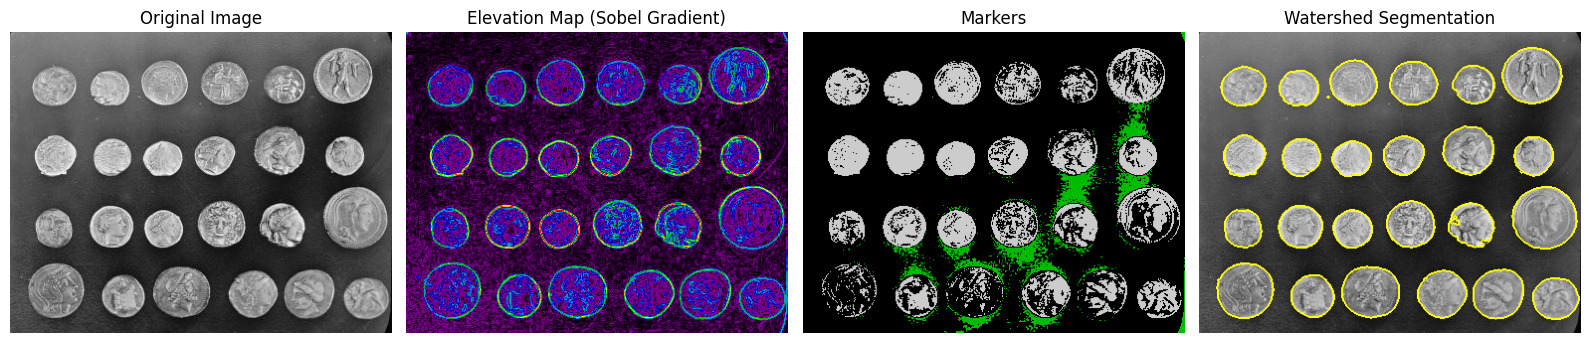

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Marker untuk latar belakang
markers[image_coins > 150] = 2  # Marker untuk objek (koin)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

## Kesimpulan Praktikum 4

Dari hasil praktikum ini dapat disimpulkan:

1. **Algoritma Watershed** bekerja dengan memanfaatkan informasi tepi (gradien) citra sebagai "peta topografi", lalu mengisi region dari titik marker hingga bertemu batas antar objek.

2. **Elevation Map (Sobel Gradient)** mendeteksi tepi objek — semakin tinggi nilainya, semakin kuat tepi yang terdeteksi, sehingga menjadi "dinding pemisah" antar region.

3. **Pemilihan marker sangat kritis:**
   - Marker yang tepat → batas antar objek terbentuk dengan baik
   - Marker yang salah atau kurang → objek bisa tergabung atau over-segmentasi

4. Watershed sangat unggul dibanding thresholding biasa untuk kasus objek yang **saling bersentuhan**, seperti koin yang berdempetan pada citra `coins`.

5. Kelemahannya adalah **sensitif terhadap noise** — noise kecil pada gradien bisa menciptakan cekungan palsu dan menghasilkan over-segmentasi jika marker tidak disiapkan dengan baik.

# Praktikum 5: Perbandingan Visual Hasil Segmentasi

## Tujuan
Praktikum ini bertujuan untuk **membandingkan secara visual** hasil dari tiga metode segmentasi yang telah dipelajari sebelumnya pada **citra yang sama**, yaitu citra `camera` dari scikit-image.

## Metode yang Dibandingkan
| Metode | Pendekatan | Keunggulan |
|---|---|---|
| **Otsu Thresholding** | Berbasis intensitas piksel | Cepat, otomatis, cocok untuk citra kontras tinggi |
| **K-Means (K=3)** | Berbasis clustering intensitas | Bisa menghasilkan lebih dari 2 segmen |
| **Watershed** | Berbasis tepi + marker | Baik untuk memisahkan objek yang bersentuhan |

## Library yang Digunakan
- `matplotlib` — visualisasi perbandingan
- `scikit-image (skimage)` — citra, filter, dan segmentasi
- `scikit-learn (sklearn)` — K-Means clustering
- `numpy` — manipulasi array
- `warnings` — menyembunyikan peringatan versi library

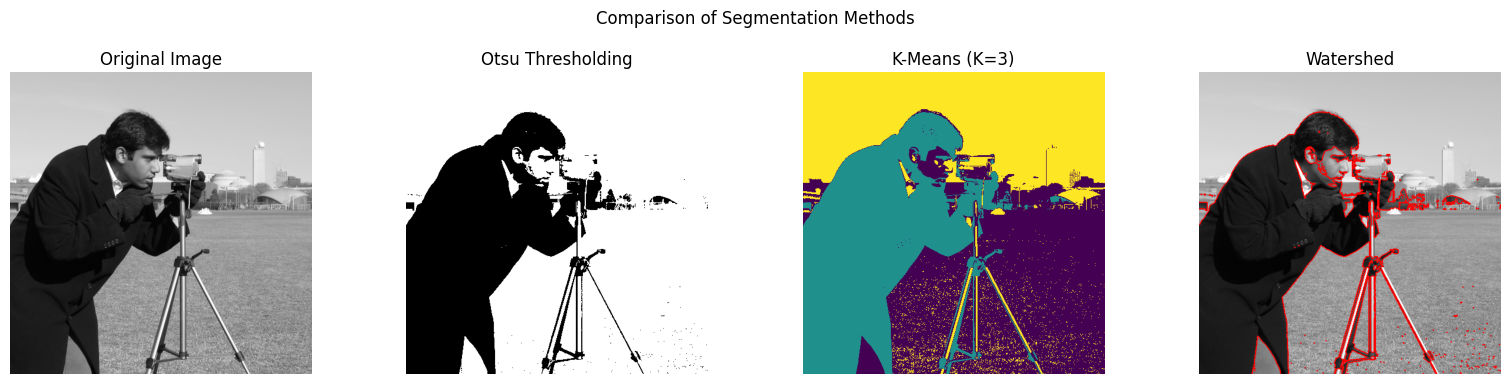

In [10]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0)  # Batas merah
)
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Kesimpulan Praktikum 5

Dari perbandingan visual ketiga metode pada citra `camera` dapat disimpulkan:

1. **Otsu Thresholding** menghasilkan segmentasi biner (hitam-putih) yang cepat dan sederhana. Cocok untuk citra dengan perbedaan kontras yang jelas, namun tidak mampu membedakan lebih dari dua region.

2. **K-Means (K=3)** mampu menghasilkan **tiga segmen** sekaligus berdasarkan kemiripan intensitas. Lebih fleksibel dari Otsu, namun hasilnya bisa berubah tergantung inisialisasi dan nilai K yang dipilih.

3. **Watershed** menghasilkan segmentasi dengan **batas tepi yang jelas** (ditandai garis merah). Pendekatan ini paling detail dalam mendeteksi batas antar objek, namun sangat bergantung pada kualitas marker dan elevation map.

## Kesimpulan Umum Jobsheet 04
Setiap metode segmentasi memiliki karakteristik dan kasus penggunaan terbaiknya masing-masing:
- Gunakan **Thresholding/Otsu** jika citra memiliki kontras tinggi dan butuh hasil cepat
- Gunakan **K-Means** jika ingin membagi citra menjadi beberapa kelompok warna/intensitas
- Gunakan **Watershed** jika objek saling bersentuhan dan detail batas sangat penting
- Gunakan **Region Growing** jika objek memiliki intensitas seragam dan posisi seed diketahui

Pemilihan metode yang tepat selalu bergantung pada **karakteristik citra** dan **tujuan akhir** dari aplikasi pengolahan citra yang dikembangkan.